# Ultrasound Lesion Tracking — Dataset Exploration

**Project:** automatic focal-liver-lesion **localization + classification + segmentation** from CEUS/RF ultrasound (Dresden → Halle external split).

This notebook is *generated* by `scripts/build_notebook.py` and organized into **phases** that mirror the project plan, so each iteration's progress is easy to follow. Rerun the builder + `nbconvert --execute` to refresh it.

| Phase | What it shows |
|---|---|
| 0 | Setup & data-root check |
| 1 | Cohort overview — class × site, mask coverage, acquisitions, QC |
| 1b | De-identification — burned-in PHI removal |
| 2 | Anatomy of a single case — files, RF/envelope geometry |
| 3 | B-mode reconstruction — DICOM vs envelope vs RF→B-mode |
| 4 | Labels & **coordinate registration** — the diagnostic (why it's hard) |
| 4b | Registration **resolved** — masks + boxes on the canonical image |
| 5 | Class galleries — example lesions per type |
| 6 | Next steps |


## Phase 0 — Setup

In [1]:
%matplotlib inline
import os, warnings, glob
warnings.simplefilter('ignore')
os.environ.setdefault('USLOC_DATA_ROOT', '/media/ahmed-el-kaffas/20TB-HDD/Puneeth/Dresden_new')
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from usloc import config as C
from usloc.data import build_cohort
from usloc.data.discover import find_case_dir, list_dicoms, list_extracted
from usloc.io import parse_rawdata_yml, read_raw, load_npy_rf, read_dicom
from usloc.io.dicom import dicom_meta
from usloc.labels import load_boxes, load_spline, rasterize_spline
from usloc.recon import envelope_to_bmode, rf_to_bmode
from usloc.viz import show_gray, draw_box, overlay_mask, montage
plt.rcParams.update({'figure.dpi':110,'font.size':9,'axes.titlesize':9,'figure.facecolor':'white'})
print('Data root :', C.DATA_ROOT)
print('Exists    :', C.DATA_ROOT.exists())
print('Classes   :', C.CLASSES)


Data root : /media/ahmed-el-kaffas/20TB-HDD/Puneeth/Dresden_new
Exists    : True
Classes   : ('fnh', 'hemangioma', 'metastasis')


## Phase 1 — Cohort overview
Every GUI-labeled case, cross-referenced with raw acquisitions, spline masks, and the clinical/QC spreadsheets. Site is derived from the case-ID prefix (`UKH…` = Halle, else Dresden).

In [2]:
cohort = build_cohort()
print('cases:', len(cohort))
display(pd.crosstab(cohort['class'], cohort['site'], margins=True))
cohort.head(8)


cases: 163


site,Dresden,Halle,All
class,,,
fnh,15,3,18
hemangioma,41,16,57
metastasis,66,22,88
All,122,41,163


,case,class,class_id,site,benign_malignant,n_tar,has_raw_dir,has_box,has_spline,ground_truth,qc_note,excluded
0,CEUS026,fnh,0,Dresden,benign,3,True,True,True,2.0,0_1,False
1,UKDCEUS029,fnh,0,Dresden,benign,2,True,True,True,2.0,,False
2,UKDCEUS060,fnh,0,Dresden,benign,2,True,True,True,2.0,,False
3,UKDCEUS080,fnh,0,Dresden,benign,2,True,True,True,2.0,,False
4,UKDCEUS117,fnh,0,Dresden,benign,2,True,True,True,2.0,,False
5,UKDCEUS181,fnh,0,Dresden,benign,2,True,True,True,2.0,,False
6,UKDCEUS193,fnh,0,Dresden,benign,4,True,True,False,2.0,schlecht abgrenzbar,False
7,UKDCEUS241,fnh,0,Dresden,benign,2,True,True,True,3.0,,False


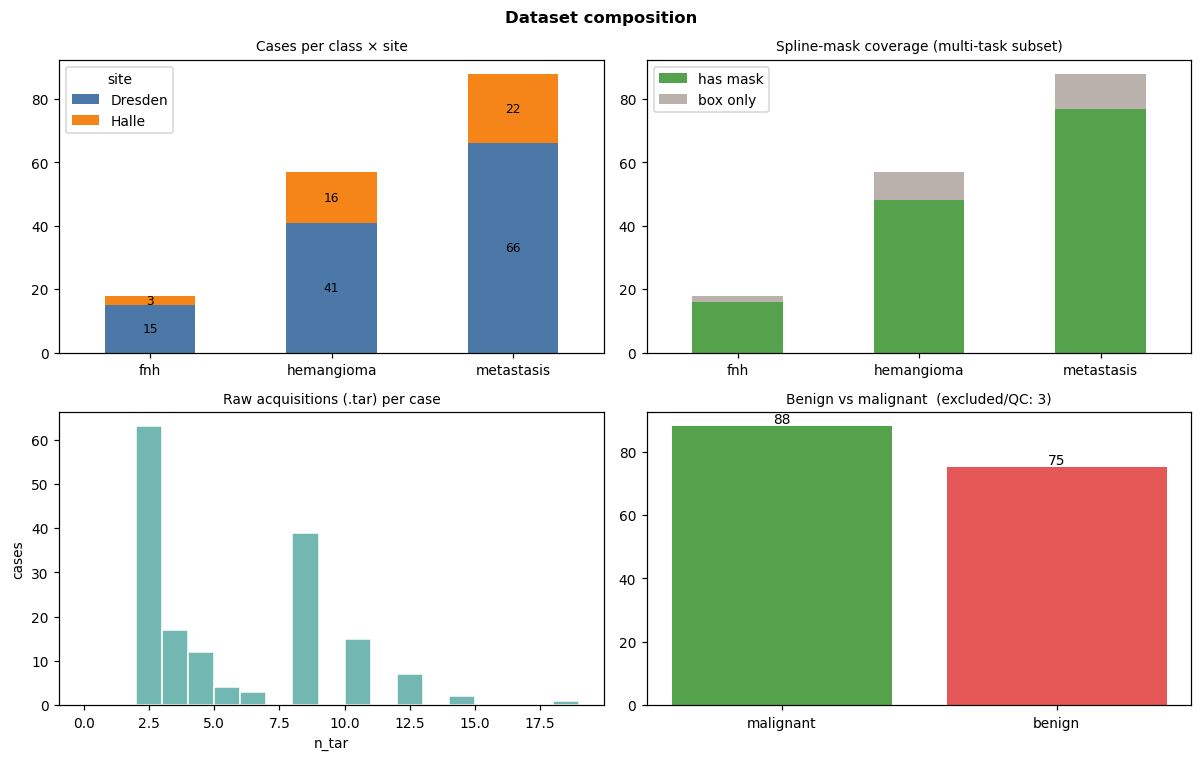

In [3]:
fig, ax = plt.subplots(2, 2, figsize=(11, 7)); fig.suptitle('Dataset composition', fontweight='bold')
# (a) class x site stacked bar
ct = pd.crosstab(cohort['class'], cohort['site'])
ct.plot(kind='bar', stacked=True, ax=ax[0,0], color=['#4C78A8','#F58518'])
ax[0,0].set_title('Cases per class × site'); ax[0,0].set_xlabel(''); ax[0,0].tick_params(axis='x', rotation=0)
for c in ax[0,0].containers: ax[0,0].bar_label(c, label_type='center', fontsize=8)
# (b) segmentation-mask coverage
cov = cohort.groupby('class')['has_spline'].agg(['sum','count'])
cov['no_mask'] = cov['count'] - cov['sum']
cov[['sum','no_mask']].rename(columns={'sum':'has mask','no_mask':'box only'}).plot(
    kind='bar', stacked=True, ax=ax[0,1], color=['#54A24B','#BAB0AC'])
ax[0,1].set_title('Spline-mask coverage (multi-task subset)'); ax[0,1].set_xlabel(''); ax[0,1].tick_params(axis='x', rotation=0)
# (c) acquisitions per case
ax[1,0].hist(cohort['n_tar'], bins=range(0, int(cohort['n_tar'].max())+2), color='#72B7B2', edgecolor='white')
ax[1,0].set_title('Raw acquisitions (.tar) per case'); ax[1,0].set_xlabel('n_tar'); ax[1,0].set_ylabel('cases')
# (d) benign/malignant and QC
bm = cohort['benign_malignant'].value_counts()
ax[1,1].bar(bm.index, bm.values, color=['#54A24B','#E45756'])
ax[1,1].set_title(f"Benign vs malignant  (excluded/QC: {int(cohort['excluded'].sum())})")
for i,v in enumerate(bm.values): ax[1,1].text(i, v, str(v), ha='center', va='bottom', fontsize=9)
plt.tight_layout(); plt.show()


## Phase 1b — De-identification (burned-in PHI removal)
The DICOM cines have identifiers **burned into the pixels** (case ID, institution, acquisition date, operator name) in the banner rows *outside* the ultrasound image. The DICOM declares the image rectangle in `SequenceOfUltrasoundRegions`; keeping only those pixels removes all burned-in PHI **without altering the ultrasound sector**. Header tags are scrubbed too. `read_dicom(deidentify=True)` is the **default**, so every image below is already de-identified. _Audit: 100% of the 490 DICOMs carry region metadata — no case relies on the geometric fallback._

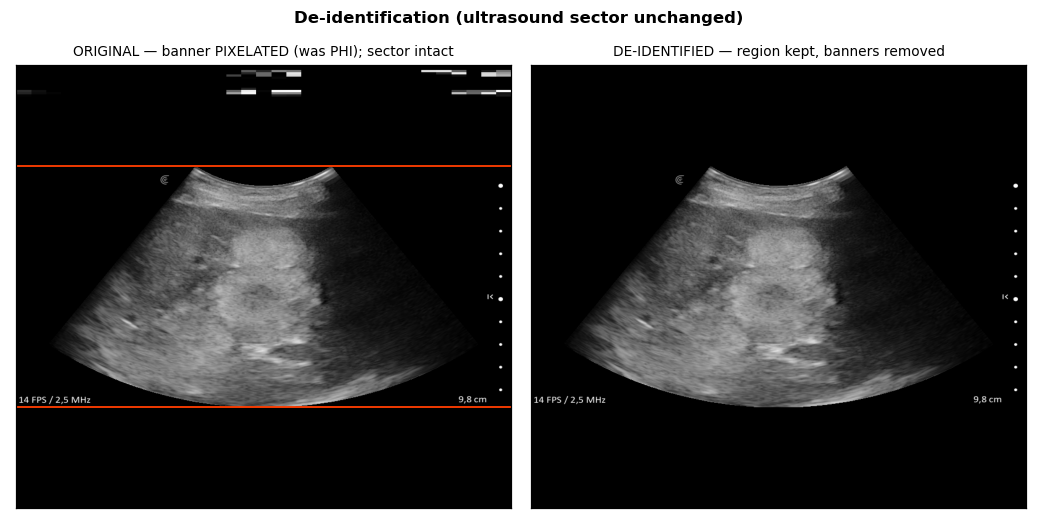

ultrasound region: Region(x0=0, y0=182, x1=799, y1=617)
header scrubbed -> OperatorsName: '' | InstitutionName: '' | PatientID kept: 'CEUS014'


In [4]:
import pydicom, cv2
from usloc.deid import ultrasound_region, deidentify_frames
dcm0 = list_dicoms(find_case_dir('CEUS014'))[0]
_, raw = read_dicom(dcm0, deidentify=False)      # raw (still has burned-in text)
ds0, clean = read_dicom(dcm0, deidentify=True)   # default: de-identified
reg = ultrasound_region(pydicom.dcmread(str(dcm0)))
f = raw.shape[0]//2
def _pixelate(a):
    h, w = a.shape
    if h < 2 or w < 2: return a
    s = cv2.resize(a, (max(1,w//24), max(1,h//4)), interpolation=cv2.INTER_LINEAR)
    return cv2.resize(s, (w, h), interpolation=cv2.INTER_NEAREST)
before = raw[f].copy()   # pixelate the burned-in banner so this panel is safe to publish
before[:reg.y0]   = _pixelate(before[:reg.y0])
before[reg.y1+1:] = _pixelate(before[reg.y1+1:])
fig, ax = plt.subplots(1, 2, figsize=(9.5, 4.8))
show_gray(ax[0], before, 'ORIGINAL — banner PIXELATED (was PHI); sector intact')
ax[0].axhline(reg.y0, color='#ff3d00', lw=1.2); ax[0].axhline(reg.y1, color='#ff3d00', lw=1.2)
show_gray(ax[1], clean[f], 'DE-IDENTIFIED — region kept, banners removed')
plt.suptitle('De-identification (ultrasound sector unchanged)', fontweight='bold'); plt.tight_layout(); plt.show()
print('ultrasound region:', reg)
print('header scrubbed -> OperatorsName:', repr(ds0.get('OperatorsName','')),
      '| InstitutionName:', repr(ds0.get('InstitutionName','')),
      '| PatientID kept:', repr(ds0.get('PatientID','')))


## Phase 2 — Anatomy of a single case
Pick one case and inspect its on-disk structure: DICOM cines, extracted RF/envelope acquisitions, and the acquisition geometry parsed from the YAML sidecars.

In [5]:
CASE = 'CEUS014'
case_dir = find_case_dir(CASE)
dcms = list_dicoms(case_dir)
ext  = list_extracted(case_dir)
print('case dir :', case_dir)
print('DICOMs   :', [p.name for p in dcms])
print('extracted:', len(ext), 'acquisition(s)')
for e in ext:
    print('  ', e.directory.name, '->', ', '.join(sorted(e.presets)))


case dir : /media/ahmed-el-kaffas/20TB-HDD/Puneeth/Dresden_new/FLL Data/johanna_samples_gui/raw_data_metastasis/CEUS014
DICOMs   : ['0_0.dcm', '0_1.dcm', '0_2.dcm', '1_0.dcm', '1_1.dcm']
extracted: 4 acquisition(s)
   raw_0_0_extracted -> C3_large
   raw_0_1_extracted -> C3_small
   raw_0_3_extracted -> L15_large
   raw_0_4_extracted -> L15_small


In [6]:
# geometry for the first preset that has both RF and envelope
def pick_preset(ext, needs=('env_raw','env_yml')):
    for e in ext:
        for pre, roles in e.presets.items():
            if all(k in roles for k in needs):
                return e, pre, roles
    return None, None, None
e_env, pre_env, roles_env = pick_preset(ext, ('env_raw','env_yml'))
e_rf,  pre_rf,  roles_rf  = pick_preset(ext, ('rf_npy',))
rows = []
for tag, roles, key in [('RF', roles_rf, 'rf_yml'), ('ENV', roles_env, 'env_yml')]:
    if roles and key in roles:
        g = parse_rawdata_yml(roles[key])
        rows.append(dict(kind=tag, lines=g.number_of_lines, samples=g.samples_per_line,
                         frames=g.frames, bytes=g.sample_bytes, depth_mm=g.imaging_depth_mm,
                         fs_MHz=g.sampling_rate_mhz, fc_MHz=g.transmit_freq_mhz,
                         probe_radius_mm=g.probe_radius_mm, type=g.kind))
pd.DataFrame(rows)


,kind,lines,samples,frames,bytes,depth_mm,fs_MHz,fc_MHz,probe_radius_mm,type
0,RF,192,1920,42,2,98.0,15.00,2.5,45.0,RF
1,ENV,192,480,42,1,98.0,3.75,2.5,45.0,B pre-scan


## Phase 3 — B-mode reconstruction
Three routes to a B-mode image: the **DICOM** display cine (already scan-converted), the **pre-scan envelope** (`*_env.raw`), and **RF → B-mode** via analytic-signal envelope + log compression. These are *pre-scan* (rectangular depth × line) for env/RF; scan-conversion comes once registration is fixed.

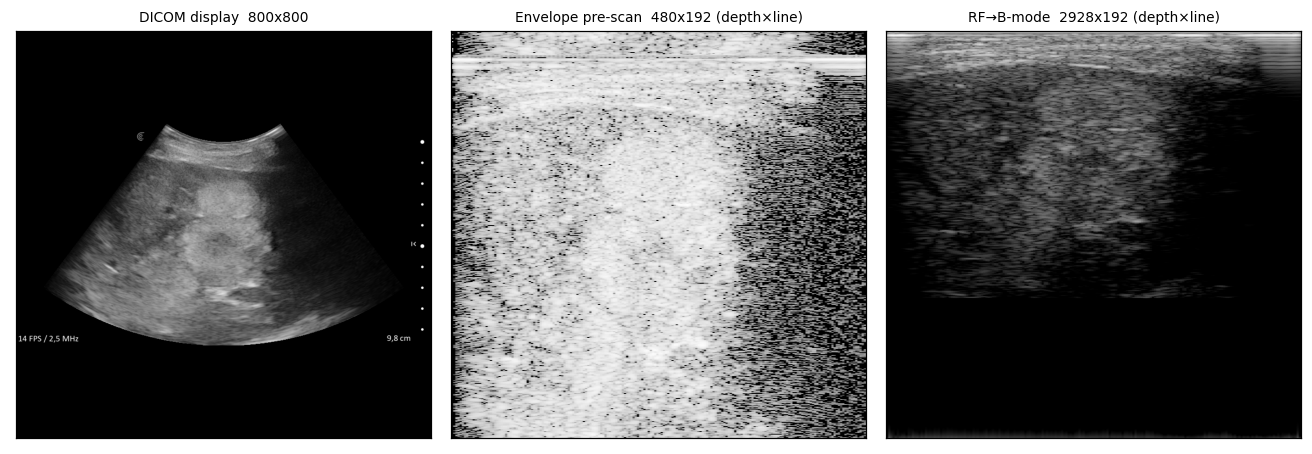

In [7]:
ds, dframes = read_dicom(dcms[0])
g_env = parse_rawdata_yml(roles_env['env_yml'])
env = read_raw(roles_env['env_raw'], g_env)                 # (frames, lines, samples)
env_bmode = envelope_to_bmode(env[0].T)                     # -> depth(samples) x line
rf = np.asarray(load_npy_rf(roles_rf['rf_npy']))            # (lines, samples, frames)
rf_bmode = rf_to_bmode(rf[:, :, 0], axis=1).T               # envelope along samples -> depth x line
fig, ax = plt.subplots(1, 3, figsize=(12, 4.2))
show_gray(ax[0], dframes[dframes.shape[0]//2], f'DICOM display  {dframes.shape[1]}x{dframes.shape[2]}')
show_gray(ax[1], env_bmode, f'Envelope pre-scan  {env_bmode.shape[0]}x{env_bmode.shape[1]} (depth×line)')
show_gray(ax[2], rf_bmode, f'RF→B-mode  {rf_bmode.shape[0]}x{rf_bmode.shape[1]} (depth×line)')
plt.tight_layout(); plt.show()


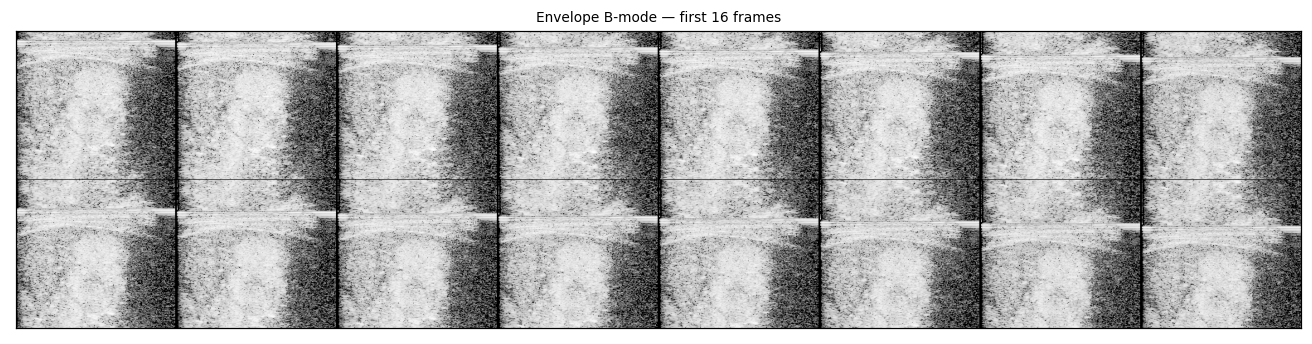

In [8]:
# envelope cine montage (first 16 frames) — sanity of temporal content
n = min(16, env.shape[0])
tiles = np.stack([envelope_to_bmode(env[i].T) for i in range(n)])
plt.figure(figsize=(12, 3.2)); show_gray(plt.gca(), montage(tiles, ncols=8), f'Envelope B-mode — first {n} frames')
plt.tight_layout(); plt.show()


env.raw size=3871076  frames*lines*samples*bytes=3870720  diff=356


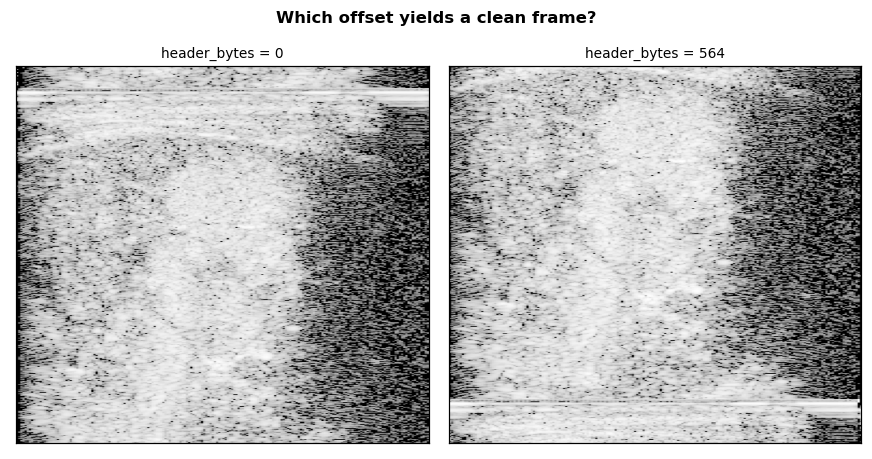

In [9]:
# Header hypothesis: filesize == frames*lines*samples*bytes + 564. Compare header_bytes 0 vs 564.
import os as _os
sz = _os.path.getsize(roles_env['env_raw']); expect = g_env.frames*g_env.number_of_lines*g_env.samples_per_line*g_env.sample_bytes
print(f'env.raw size={sz}  frames*lines*samples*bytes={expect}  diff={sz-expect}')
e0 = envelope_to_bmode(read_raw(roles_env['env_raw'], g_env, header_bytes=0)[0].T)
e5 = envelope_to_bmode(read_raw(roles_env['env_raw'], g_env, header_bytes=C.RAW_TAIL_BYTES)[0].T)
fig, ax = plt.subplots(1, 2, figsize=(8, 4.2))
show_gray(ax[0], e0, 'header_bytes = 0'); show_gray(ax[1], e5, f'header_bytes = {C.RAW_TAIL_BYTES}')
plt.suptitle('Which offset yields a clean frame?', fontweight='bold'); plt.tight_layout(); plt.show()


## Phase 4 — Labels & coordinate registration ⚠️
The **critical open task**: GUI boxes, spline masks, and the DICOM display live in *different* coordinate systems. Here we print their coordinate ranges against each candidate image's dimensions and overlay them, to diagnose which space each label belongs to.

In [10]:
boxes = load_boxes(glob.glob(str(C.GUI_ROOT/'gui_*'/f'{CASE}.xlsx'))[0])
spl = load_spline(str(C.FLL_ROI_DIR/f'{CASE}_roi.pkl'))
print('BOXES:')
for b in boxes: print(f'  {b.roi_kind:5} device={b.device} frame={b.frame} xyxy={tuple(round(v,1) for v in b.xyxy)}')
print(f'SPLINE: scan={spl.scan_name} frame={spl.frame} n={len(spl.x)} '
      f'x[{spl.x.min():.0f},{spl.x.max():.0f}] y[{spl.y.min():.0f},{spl.y.max():.0f}]')
print('\nCandidate image dims:')
print(f'  DICOM display : {dframes.shape[1]} x {dframes.shape[2]}')
print(f'  ENV pre-scan  : {env_bmode.shape[0]} (depth) x {env_bmode.shape[1]} (line)')
print(f'  RF grid       : {rf.shape[1]} (samples) x {rf.shape[0]} (lines)')


BOXES:
  large device=C3 frame=0 xyxy=(322.0, 67.0, 983.0, 134.0)
  small device=C3 frame=0 xyxy=(433.0, 74.0, 842.0, 123.0)
SPLINE: scan=raw_0_0 frame=8 n=143 x[352,522] y[94,247]

Candidate image dims:
  DICOM display : 800 x 800
  ENV pre-scan  : 480 (depth) x 192 (line)
  RF grid       : 2928 (samples) x 192 (lines)


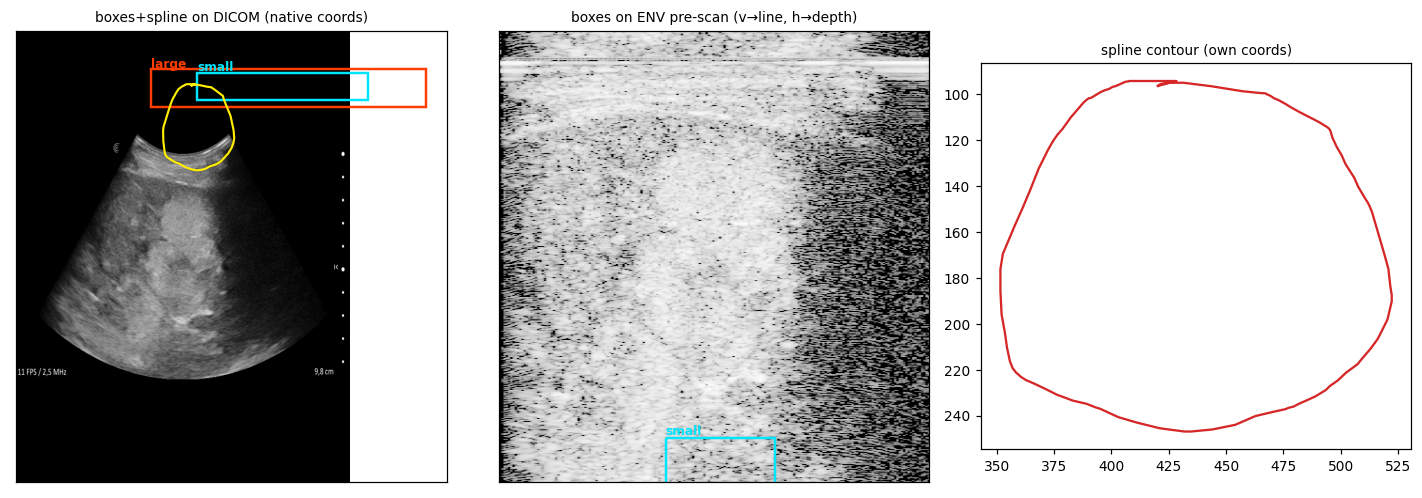

NOTE: overlays are diagnostic — final registration transform is resolved in the calibration step.


In [11]:
# Overlay attempts (exploratory): box + spline on DICOM and on envelope pre-scan, native coords.
small = next((b for b in boxes if b.roi_kind=='small'), boxes[0])
large = next((b for b in boxes if b.roi_kind=='large'), boxes[0])
fig, ax = plt.subplots(1, 3, figsize=(13, 4.6))
# (1) on DICOM (native label coords) — expect mismatch if labels are in raw grid
show_gray(ax[0], dframes[0], 'boxes+spline on DICOM (native coords)')
draw_box(ax[0], small.xyxy, '#00e5ff', 'small'); draw_box(ax[0], large.xyxy, '#ff3d00', 'large')
ax[0].plot(spl.x, spl.y, '-', color='#ffee00', lw=1.4)
# (2) on envelope pre-scan (depth×line): label h→? v→? — try v as line (x), h as depth (y)
show_gray(ax[1], env_bmode, 'boxes on ENV pre-scan (v→line, h→depth)')
draw_box(ax[1], (small.v1, small.h1, small.v2, small.h2), '#00e5ff', 'small')
# (3) spline on its own extent (what shape is it?)
ax[2].plot(np.append(spl.x, spl.x[0]), np.append(spl.y, spl.y[0]), '-', color='#d62728')
ax[2].invert_yaxis(); ax[2].set_aspect('equal'); ax[2].set_title('spline contour (own coords)')
plt.tight_layout(); plt.show()
print('NOTE: overlays are diagnostic — final registration transform is resolved in the calibration step.')


## Phase 4b — Registration resolved ✅
Solved by inspecting coordinate ranges + overlays:

* **Spline masks** are in the **scan-converted sector-crop space** → DICOM coords are `(x + region.x0, y + region.y0)`, and `spline.Frame` indexes `0_0.dcm` (= `raw_0_0`).
* **GUI boxes** are in the pre-scan **RF grid** of `raw_0_0` (h→sample, v→line); for the 142 spline cases the bounding box is derived directly from the mask.

Canonical training image = the **de-identified sector crop** of `0_0.dcm` at the annotated frame. `usloc.labels.register_case(case)` returns `(image, mask, bbox)` ready for export. Below: a QA gallery across both sites, all 3 classes, and varying region offsets.

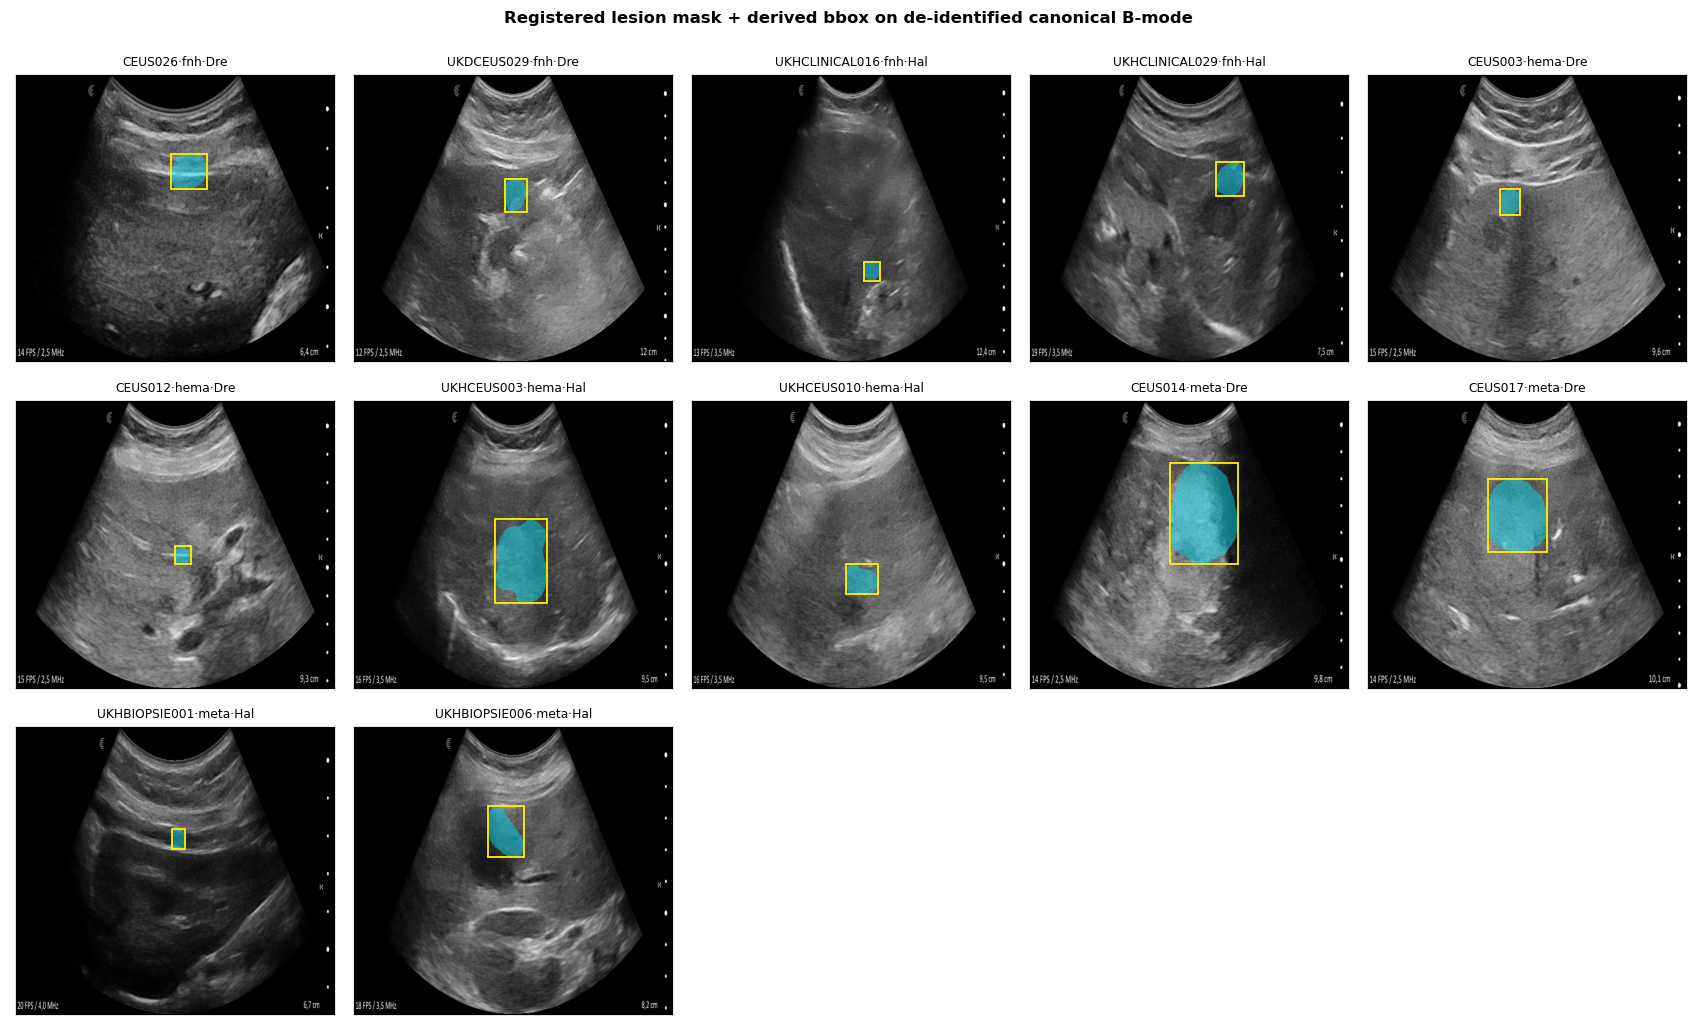

In [12]:
from usloc.labels import register_case
spl_cohort = cohort[cohort.has_spline]
picks = []
for cls in C.CLASSES:
    for site in ['Dresden','Halle']:
        picks += list(spl_cohort[(spl_cohort['class']==cls)&(spl_cohort['site']==site)]['case'].head(2))
picks = picks[:15]
ncol=5; nrow=int(np.ceil(len(picks)/ncol))
fig, ax = plt.subplots(nrow, ncol, figsize=(3.1*ncol, 3.1*nrow), squeeze=False)
for i in range(nrow*ncol):
    a = ax[i//ncol][i%ncol]; a.set_xticks([]); a.set_yticks([])
    if i >= len(picks): a.axis('off'); continue
    s = register_case(picks[i], space='crop')
    if s is None: a.axis('off'); continue
    a.imshow(overlay_mask(s.image, s.mask, (0,229,255), 0.45), aspect='auto')
    if s.bbox: draw_box(a, s.bbox, '#ffee00', lw=1.2)
    row = cohort[cohort.case==picks[i]].iloc[0]
    a.set_title(f"{picks[i]}·{row['class'][:4]}·{row['site'][:3]}", fontsize=8)
plt.suptitle('Registered lesion mask + derived bbox on de-identified canonical B-mode', fontweight='bold', y=1.0)
plt.tight_layout(); plt.show()


## Phase 5 — Class galleries
A representative DICOM frame per case for a few cases of each class — a quick visual sense of how FNH, hemangioma and metastasis look in this cohort.

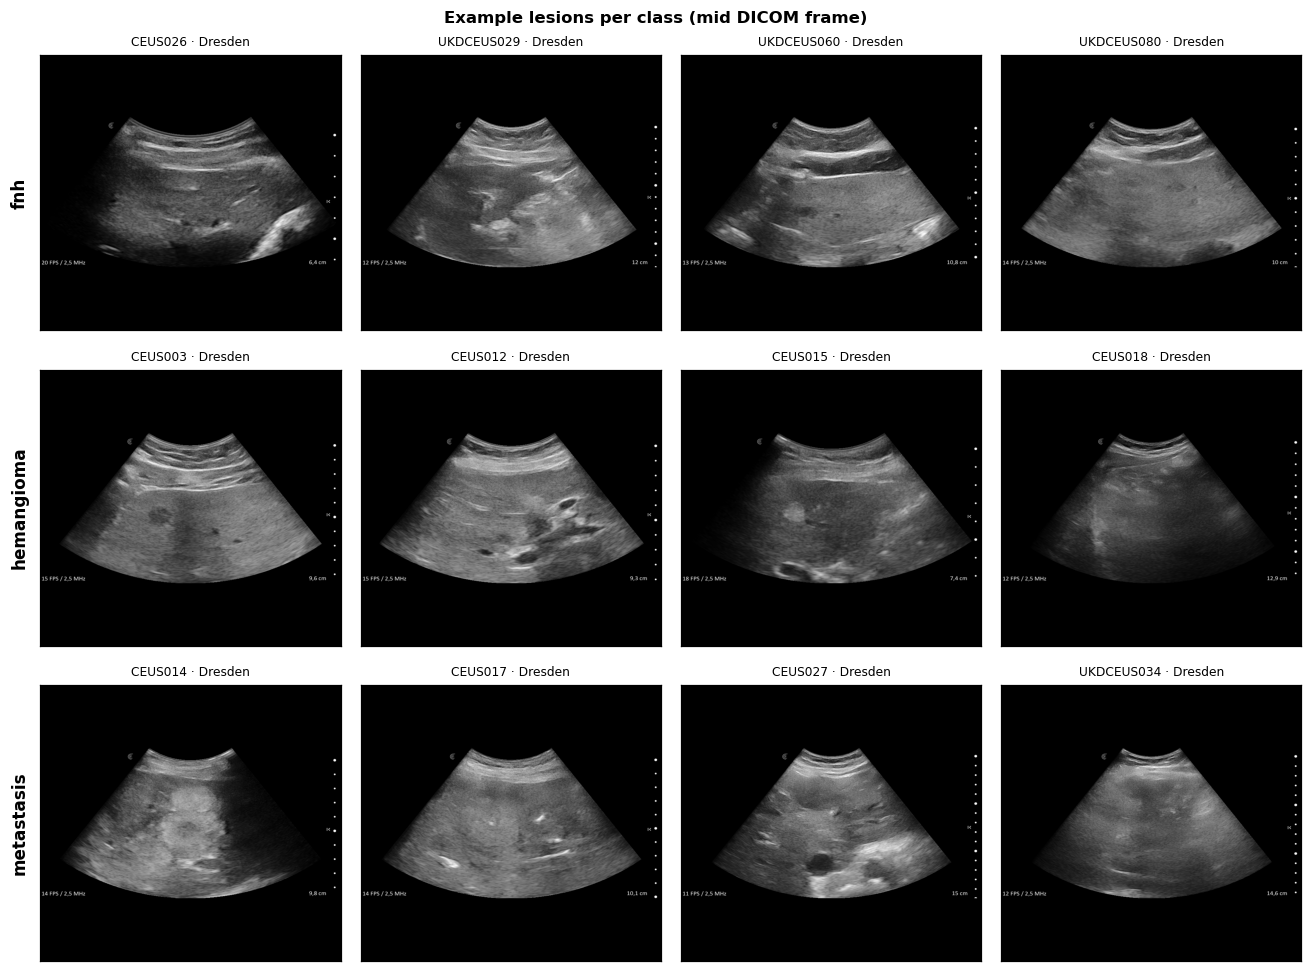

In [13]:
def rep_frame(case):
    cd = find_case_dir(case)
    if cd is None: return None
    ds_ = list_dicoms(cd)
    if not ds_: return None
    try:
        _, fr = read_dicom(ds_[0]); return fr[fr.shape[0]//2]
    except Exception: return None

per_class = 4
fig, ax = plt.subplots(len(C.CLASSES), per_class, figsize=(3*per_class, 3*len(C.CLASSES)))
for r, cls in enumerate(C.CLASSES):
    picks = cohort[(cohort['class']==cls) & (cohort['has_raw_dir'])].head(per_class)
    for c in range(per_class):
        a = ax[r, c]; a.set_xticks([]); a.set_yticks([])
        if c < len(picks):
            row = picks.iloc[c]; img = rep_frame(row['case'])
            if img is not None:
                a.imshow(img, cmap='gray', aspect='auto')
            a.set_title(f"{row['case']} · {row['site']}", fontsize=8)
        if c == 0:
            a.set_ylabel(cls, fontsize=11, fontweight='bold')
plt.suptitle('Example lesions per class (mid DICOM frame)', fontweight='bold'); plt.tight_layout(); plt.show()


## Phase 6 — Next steps
1. **Resolve label↔image registration** (Phase 4): fix the transform mapping GUI boxes & splines onto a single canonical B-mode; add a QA overlay gallery across sites/classes.
2. **Scan-conversion** of the curvilinear geometry so pre-scan → true B-mode matches the DICOM.
3. **Dataset export** (YOLO-seg + COCO) with boxes + masks + class, honoring the Dresden/Halle split and QC exclusions.
4. **Baseline** YOLO11-seg (box+mask+class), Dresden CV → locked Halle external test.
5. **RF value ablation**: B-mode vs +raw-RF vs +QUS parametric maps.

_Each becomes a new phase / notebook so progress stays trackable across iterations._